<a href="https://colab.research.google.com/github/ilia-kuznetsov-hds/statistical_modelling/blob/main/HDAT_9600_01_EDA_of_Heart_Rate_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

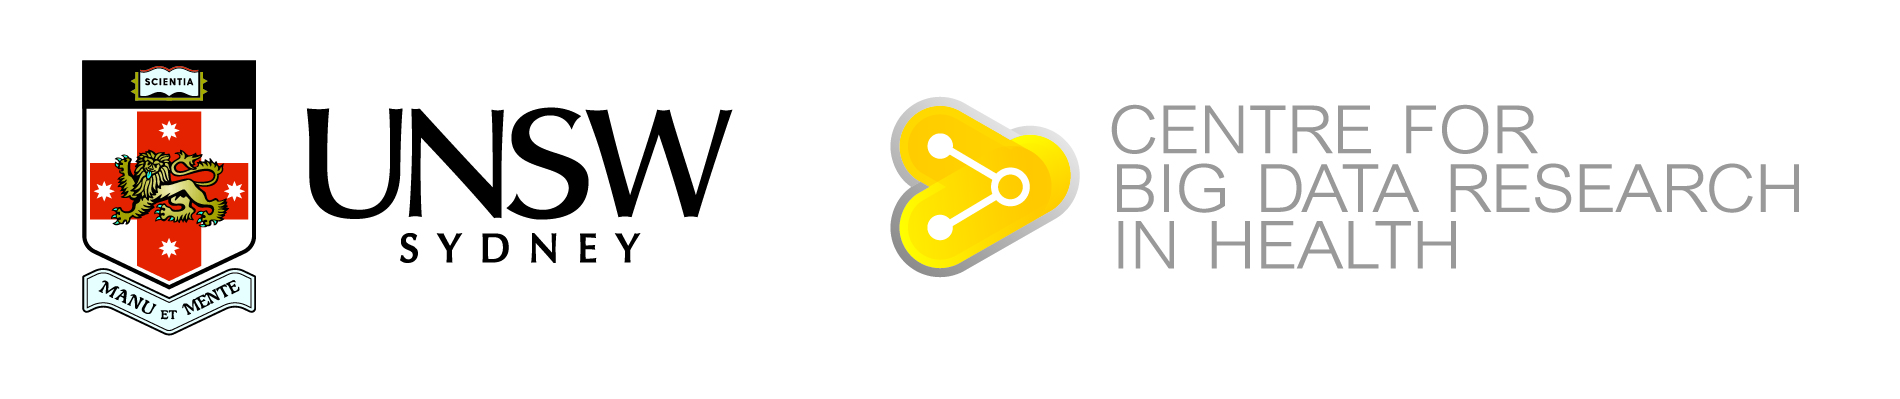

# Notebook Overview: Heart Rate EDA

This notebook performs an Exploratory Data Analysis (EDA) on a heart rate dataset. It covers data importation, structural investigation, missing value assessment, univariate distribution analysis, and co-variation studies using R.

**Acknowlegements:**
- **Course:** Part of Statistical Modelling I, UNSW (T2 2024).
- **Author:** Task and study examples authored by [Andrew Blance](https://www.unsw.edu.au/research/cbdrh/about-us/people/andrew-blance).

## Data Dictionary

| Variable | Description | Type |
| :--- | :--- | :--- |
| **X** | Participant ID | Numeric (ID) |
| **age** | Age of the participant (years) | Numeric |
| **sex** | Gender of the participant (Male/Female) | Character |
| **height** | Height of the participant (cm) | Numeric |
| **weight** | Weight of the participant (kg) | Numeric |
| **systol** | Systolic blood pressure (mmHg) | Numeric |
| **diast** | Diastolic blood pressure (mmHg) | Numeric |
| **puls** | Resting heart rate (beats per minute) | Numeric |
| **choles** | Total cholesterol (mg/dL) | Numeric |
| **bmi** | Body Mass Index ($kg/m^2$) | Numeric |
| **smoker** | Smoking status (Current/Former/Never) | Character |
| **exer** | Exercise frequency (Regular/Occasional/None) | Character |

# Imports

In [1]:
# Install packages if not already installed
if(!"dplyr" %in% installed.packages()) install.packages("dplyr", repos = "https://cran.ms.unimelb.edu.au")
if(!"tidyr" %in% installed.packages()) install.packages("tidyr", repos = "https://cran.ms.unimelb.edu.au")
if(!"ggplot2" %in% installed.packages()) install.packages("ggplot2", repos = "https://cran.ms.unimelb.edu.au")
if(!"psych" %in% installed.packages()) install.packages("psych", repos = "https://cran.ms.unimelb.edu.au")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’




In [2]:
# This chunk calls the libraries. "dplyr" and "tidyr" are both very useful for manipulating data frames.
# "ggplot" is very useful for plots - it allows a greater degree of control over the appearance of plots.
# NOTE: the "tidyverse" package is an umbrella package that loads all three of these libraries in one go.
library(dplyr)
library(tidyr)
library(ggplot2)
# The "psych" package is an optional one - it enables a nice summary table through the describe function
# which can be helpful in EDA.
library(psych)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha




# Exploratory Data Analysis

Note: This is not an exhaustive EDA - you might be starting to get the idea that this part of the analysis process can be pretty time-consuming to do thoroughly! Hopefully some of the examples below will give you the ideas and starting point though for things you want to look at.


## First step - import your data

In [4]:
# As the data were provided in a .csv file we need to read it in using the read.csv function.
# Change this filepath to where you have saved this dataset if you want to run this file.
# I have called the dataset "dat"
dat <- read.csv("hdat9600_heart_rate.csv")

# The length function is useful for looking at the dimensions of the data frame.
# If I apply length to a data frame it will give me the number of columns
length(dat)
# If I apply length to just one column in the data frame it will give the number of rows.
length(dat[,1])

# Alternatively:
ncol(dat)
nrow(dat)

[1] 12

[1] 619

[1] 12

[1] 619

#### Analytical notes:

There are 619 observations and 12 variables.

## Investigate the data structure

What are the different variables?

In [5]:
# ls() will list the column names
ls(dat)

[1] "age"    "bmi"    "choles" "diast"  "exer"   "height" "puls"   "sex"   
 [9] "smoker" "systol" "weight" "X"

What types of variables are they?

In [6]:
# str() will provide the structure of the data frame as well as give you the number of obs and variables
str(dat)

'data.frame':	619 obs. of  12 variables:
 $ X     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sex   : chr  "female" "male" "male" "male" ...
 $ age   : int  42 59 42 26 61 26 58 54 26 22 ...
 $ systol: int  134 124 132 120 159 130 136 124 148 125 ...
 $ diast : int  70 72 88 70 80 78 70 84 87 67 ...
 $ puls  : int  93 76 100 49 72 50 71 59 89 83 ...
 $ height: num  146 181 174 180 170 ...
 $ weight: num  52.4 75.8 74.2 65.4 72.6 ...
 $ choles: num  5.1 5.8 4.9 4.7 5.8 ...
 $ smoker: chr  "no" "yes" "no" "yes" ...
 $ exer  : chr  "regularly" "regularly" "regularly" "regularly" ...
 $ bmi   : num  24.6 23.1 24.5 20.2 25.1 ...


#### Analytical notes:

We have an ID variable (X)

Three character variables (sex, smoker, exer)

The rest are numeric variables but we have:
* four stored as integers (age, systol, diast, puls)
* four as numbers (height, weight, choles, bmi)

In [7]:
# I am going to split my data into two groups of variables - categorical variables and continuous variables
cat_var <- c("sex", "smoker","exer")
cont_var <- c("age", "systol", "diast","puls","height","weight","choles","bmi")
ls(dat[,cat_var])
ls(dat[,cont_var])

# An alternative way of doing this is to use functions:
dat.cont <- select(dat[,2:12],is.numeric) # note I am skipping over the ID variable so it is not included
dat.cat <- select(dat,is.character)

[1] "exer"   "sex"    "smoker"

[1] "age"    "bmi"    "choles" "diast"  "height" "puls"   "systol" "weight"

Warning message:
“Use of bare predicate functions was deprecated in tidyselect 1.1.0.
ℹ Please use wrap predicates in `where()` instead.
  # Was:
  data %>% select(is.numeric)

  # Now:
  data %>% select(where(is.numeric))”
Warning message:
“Use of bare predicate functions was deprecated in tidyselect 1.1.0.
ℹ Please use wrap predicates in `where()` instead.
  # Was:
  data %>% select(is.character)

  # Now:
  data %>% select(where(is.character))”


## Check for missing data

### First for Continuous data

In [8]:
# The summary function will provide basic stats on distribution for continuous variables
summary(dat.cont)

      age            systol          diast             puls       
 Min.   :16.00   Min.   : 70.0   Min.   : 51.00   Min.   : 26.00  
 1st Qu.:28.00   1st Qu.:121.0   1st Qu.: 74.00   1st Qu.: 62.50  
 Median :39.00   Median :132.0   Median : 80.00   Median : 70.00  
 Mean   :38.96   Mean   :133.6   Mean   : 80.36   Mean   : 71.57  
 3rd Qu.:49.00   3rd Qu.:143.0   3rd Qu.: 86.00   3rd Qu.: 79.00  
 Max.   :80.00   Max.   :200.0   Max.   :117.00   Max.   :128.00  
 NA's   :1                                                        
     height          weight           choles           bmi       
 Min.   : 67.0   Min.   : 32.20   Min.   :2.800   Min.   :17.01  
 1st Qu.:162.5   1st Qu.: 61.00   1st Qu.:4.700   1st Qu.:21.85  
 Median :170.5   Median : 69.50   Median :5.300   Median :23.78  
 Mean   :170.2   Mean   : 70.35   Mean   :5.416   Mean   :24.15  
 3rd Qu.:178.0   3rd Qu.: 78.60   3rd Qu.:6.100   3rd Qu.:26.04  
 Max.   :195.5   Max.   :117.00   Max.   :9.000   Max.   :43.29  
 N

#### Analytical notes:

The variable _choles_ looks like it has 266 'NA's suggesting a lot of missing data!! There are also a small number of missing values for age(1), height(2), weight(2), and bmi(3).

### Now for Categorical data

In [9]:
# For categorical variables it may be easier to summarise in a table or series of tables, if you include
# the option "exclude=NULL" it will show the 'NA's.
# NOTE also the round function to reduce the number of decimal places displayed.
t1 <- table(dat.cat$sex, exclude=NULL)
t1
round(prop.table(t1), digits=2)

t2 <- table(dat.cat$exer, exclude=NULL)
t2
round(prop.table(t2), digits=2)

t3 <- table(dat.cat$smoker, exclude=NULL)
t3
round(prop.table(t3), digits=2)


female   male 
   273    346 


female   male 
  0.44   0.56 


    never regularly sometimes      <NA> 
       59       239        75       246 


    never regularly sometimes      <NA> 
     0.10      0.39      0.12      0.40 


 no yes 
434 185 


 no yes 
0.7 0.3 

#### Analytical notes:

The variable _exer_ also looks to have 246 responses coded as 'NA' so a lot of missing data! This wouldn't have been obvious if you just ran the summary function for this variable as the missing values have been entered in character format as "NA" so they look like a valid response.

## Check univariate distributions

You can embed plots, for example we may want to look at the distribution of age:

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_count()`).”


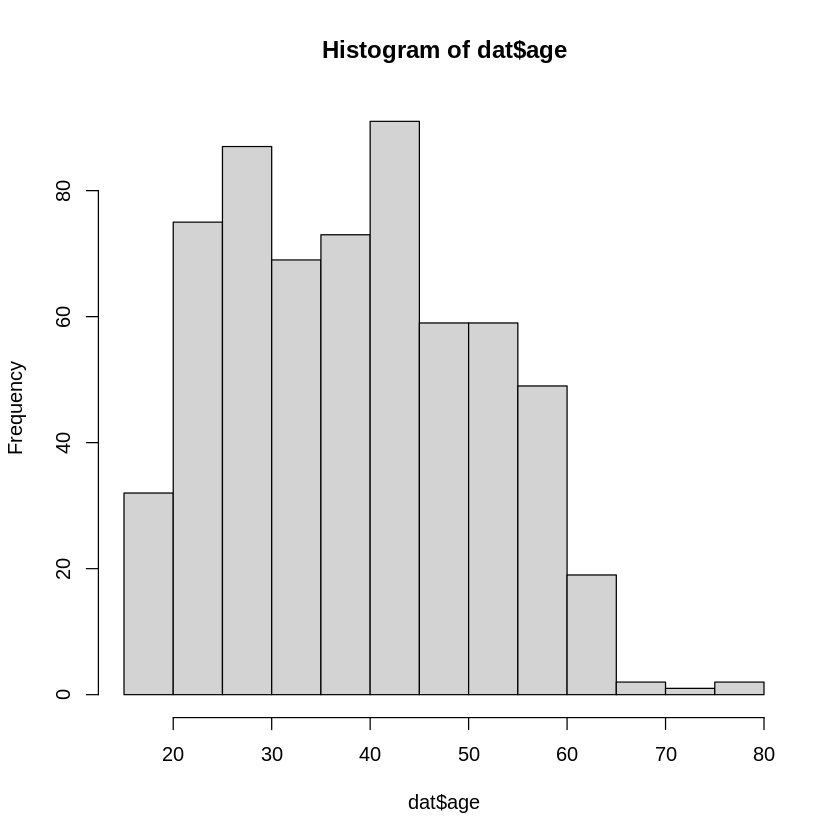

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


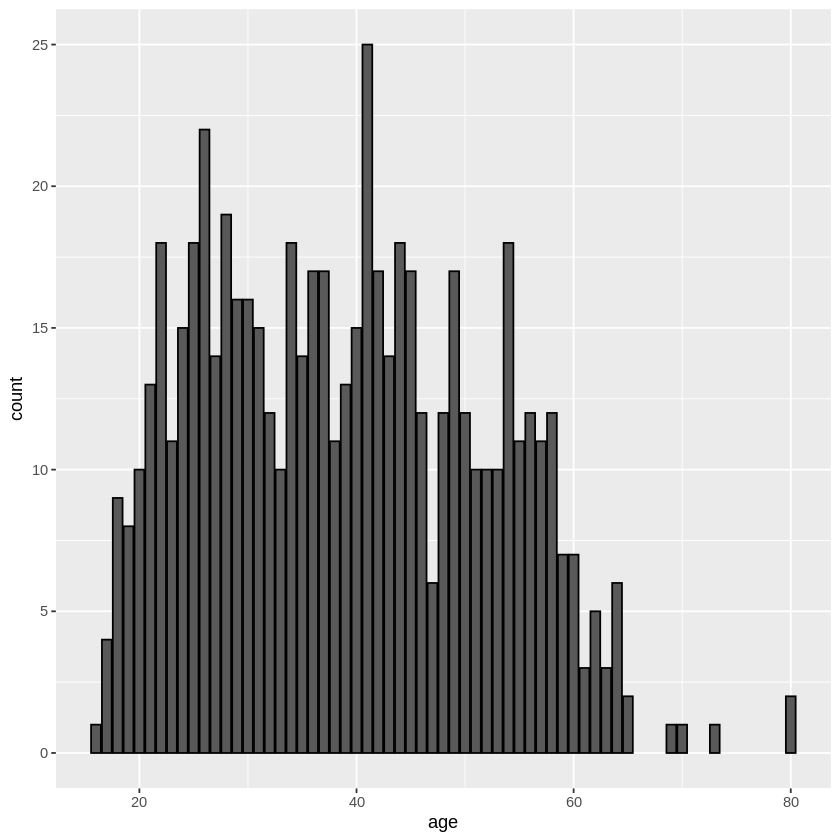

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


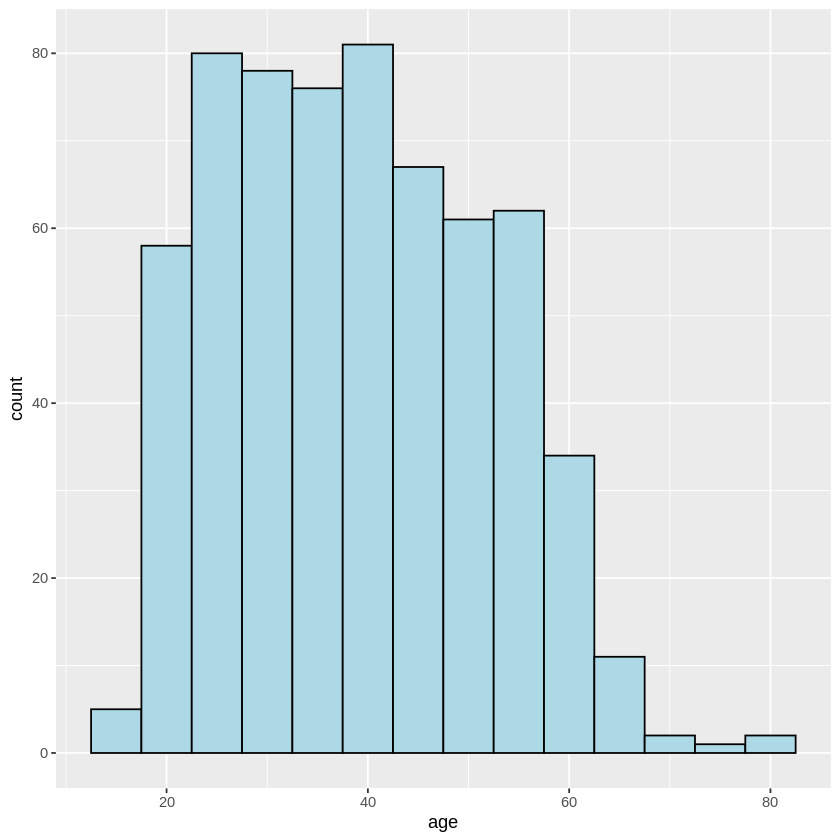

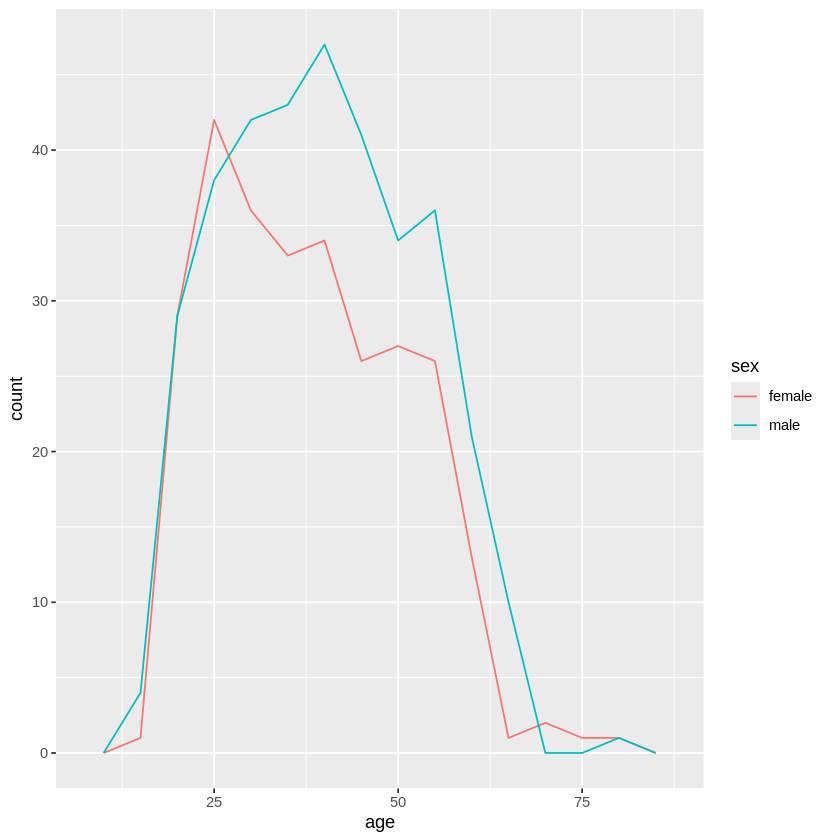

In [10]:
# The hist() function from base R will produce a nice standard histogram
hist(dat$age)

# Three other ways of producing a distribution plot using ggplot
ggplot(data = dat) +
  geom_bar(mapping = aes(x = age), color='black')
# The geom_histogram allows you to specify the binwidth to control the width of the bars
ggplot(data = dat) +
  geom_histogram(mapping = aes(x = age), binwidth = 5, color='black', fill='lightblue')
#This one allows a nice overlay between males and females as we define the colour of the line based on sex:
ggplot(data = dat) +
  geom_freqpoly(mapping = aes(x = age, colour=sex), binwidth = 5)

A much quicker way of looking at all the continuous distributions at once

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 274 rows containing non-finite outside the scale range (`stat_bin()`).”


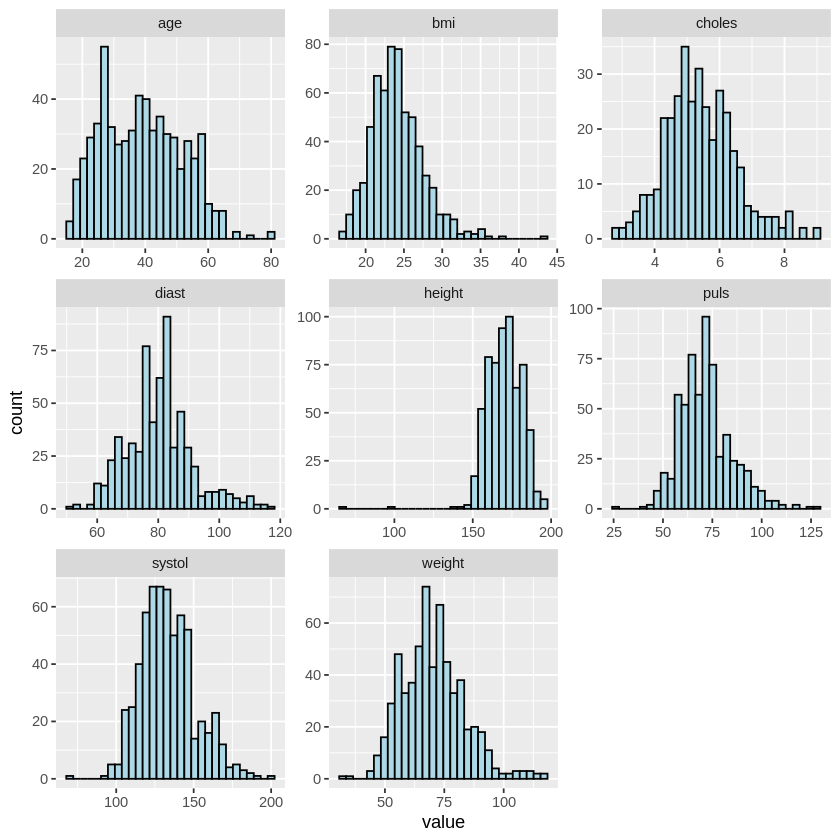

In [11]:
# This code first reshapes the data and then uses a facet_wrap to plot the individual charts in a grid
dat.cont %>%
  gather() %>%
  ggplot(aes(value)) +
    facet_wrap(~ key, scales = "free") +
    geom_histogram(color='black', fill='lightblue')

#### Analytical notes:

This saved quite a lot of time as we can look at them all at once! Immediately we can see that something might be going on with height as there are some outliers. There is also one very high BMI value. The other variables look ok and are fairly normally distributed.

Another way we can investigate distributions is by calculating some stats.

Calculate the mean and sd (using the describe function in the psych package )

In [12]:
# This uses the describe function from the "Psych" package, but you can get these stats using base R also.
des <- describe(dat.cont)
des[,c("n","mean","sd","median","min","max","skew","kurtosis")] #I have just selected the stats I am interested in

,n,mean,sd,median,min,max,skew,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
age,618,38.959547,12.685064,39.0000,16.0000,80.00000,0.2703814,-0.7170627
systol,619,133.576737,17.512414,132.0000,70.0000,200.00000,0.4951971,0.5075723
diast,619,80.358643,10.679835,80.0000,51.0000,117.00000,0.4642236,0.6791383
puls,619,71.565428,13.250640,70.0000,26.0000,128.00000,0.6728481,1.0592237
height,617,170.172447,11.355698,170.5000,67.0000,195.50000,-1.5446701,11.9447675
weight,617,70.345219,13.143605,69.5000,32.2000,117.00000,0.5466693,0.6262545
choles,353,5.416147,1.102886,5.3000,2.8000,9.00000,0.4565649,0.3956355
bmi,616,24.146621,3.388523,23.7838,17.0068,43.28537,0.9460947,2.2671535


Skew and Kurtosis look really large for height and the minimum height of 67 looks implausible. We assume that we are talking about cms for height but we would need to check the data dictionary if available.
Skew measures the symmetry of a distribution and kurtosis measures the "pointiness" or "flatness" in comparison to the normal distribution. Both are centred around zero, so low absolute values are what we are looking for and high absolute values signal a non-normal distribution. These types of statistics are optional and a visual inspection will normally give you the same idea.    


## Investigating co-variation

We also need to look at the relationships between variables

### Pairs of Continuous variables

In [13]:
# The pairs function in base R will produce a matrix of scatterplots for each combination of variables
# - let's focus on the continuous variables first


integer(0)

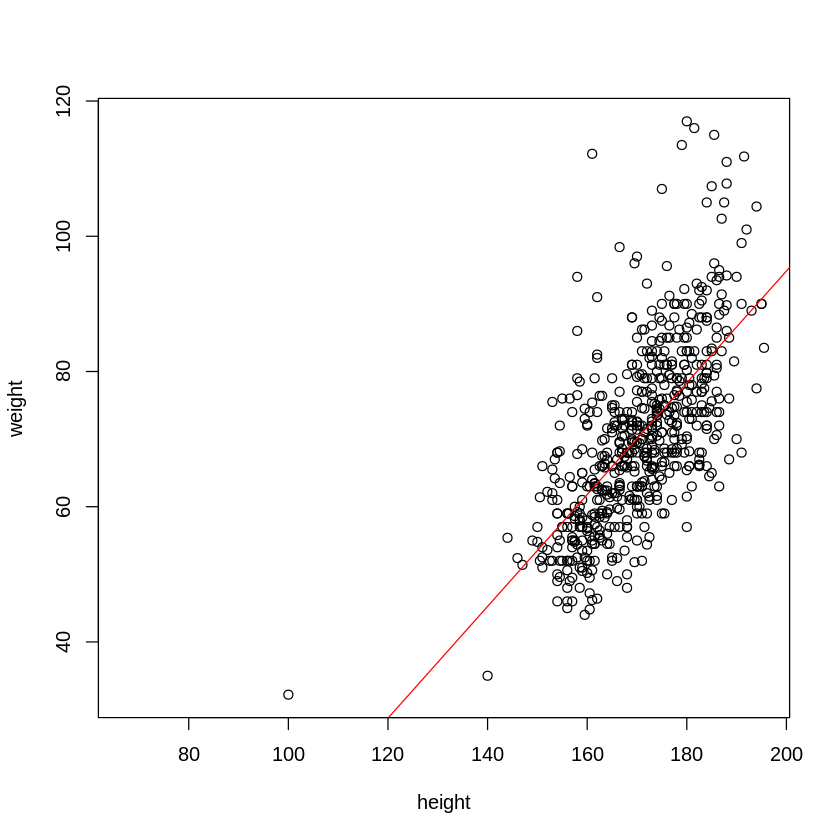

In [14]:
# We can look at any of these pairs in more detail by running them separately:
attach(dat.cont)
p<- plot(height,weight)+
  abline(lm(weight~height), col='red')  #this adds a regression line
p

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


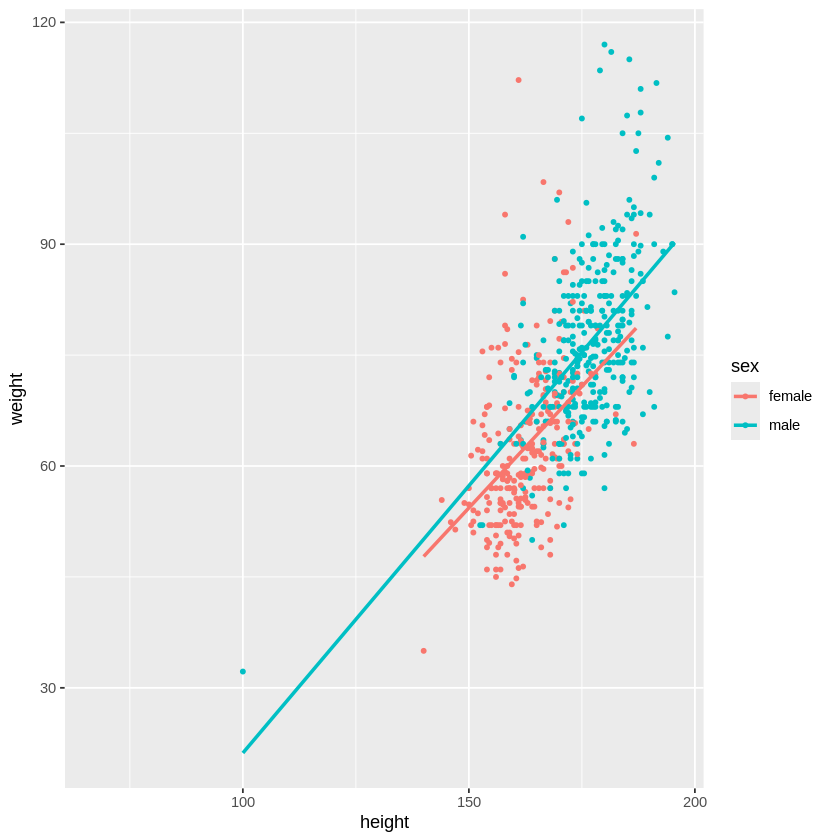

In [15]:
# Using ggplot we can also add in color depending on another variable - eg.Sex
ggplot(dat, aes(x=height, y=weight, color=sex)) +
    geom_point(size=1)+
    geom_smooth(method = "lm", se = FALSE)  #this adds two regression lines

A correlation matrix is also useful:

In [16]:
# The cor() function produces a basic correlation matrix. You will need to specify what type of correlation
# coefficient to display and what to do about missing data.
cormat <- round(cor(dat.cont, method = "pearson", use = "complete.obs"), digits=2)
cormat

,age,systol,diast,puls,height,weight,choles,bmi
age,1.00,0.30,0.31,0.00,0.01,0.12,0.35,0.16
systol,0.30,1.00,0.62,0.07,0.22,0.34,0.22,0.26
diast,0.31,0.62,1.00,0.06,0.14,0.30,0.20,0.28
puls,0.00,0.07,0.06,1.00,-0.10,-0.09,0.07,-0.03
height,0.01,0.22,0.14,-0.10,1.00,0.66,-0.08,-0.03
weight,0.12,0.34,0.30,-0.09,0.66,1.00,0.07,0.73
choles,0.35,0.22,0.20,0.07,-0.08,0.07,1.00,0.16
bmi,0.16,0.26,0.28,-0.03,-0.03,0.73,0.16,1.00


#### Analytical notes:

The strongest correlations are between bmi & weight; height & weight; and diast & systol.
There are quite a few more moderate correlations. For example age shows some correlation with both systolic and diastolic blood pressure measures and with cholesterol. The two bp measures (diast and systol) also show correlation with weight. We would need to consider whether it makes sense to include all of these correlated variables in our analysis - particularly those variables with a strong correlation. We may run into problems with multicollinearity.

### Categorical and Continuous variables

Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


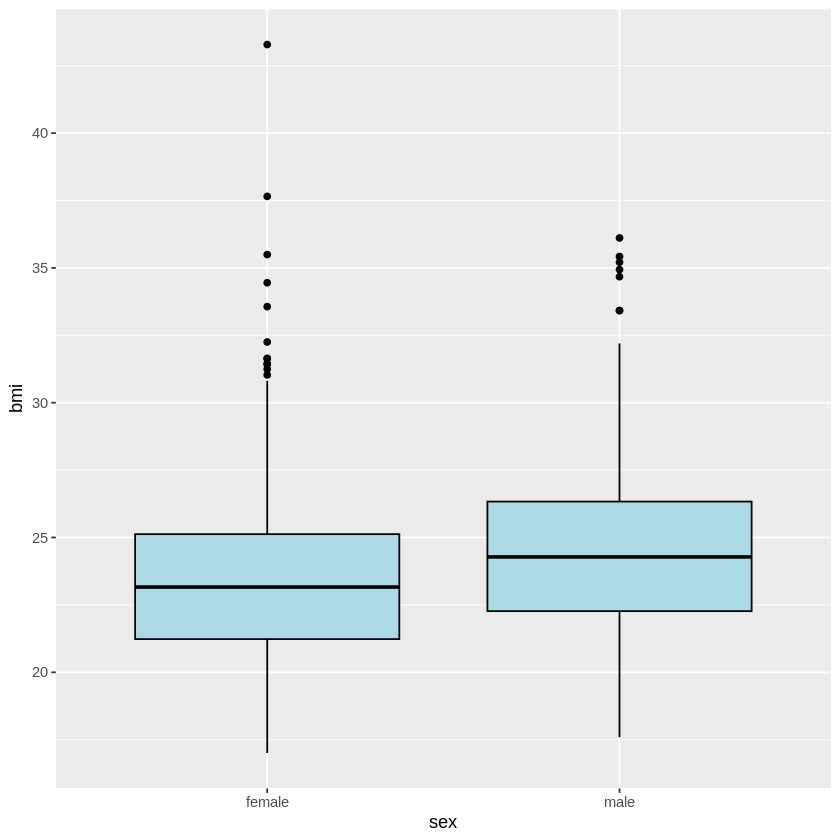

Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


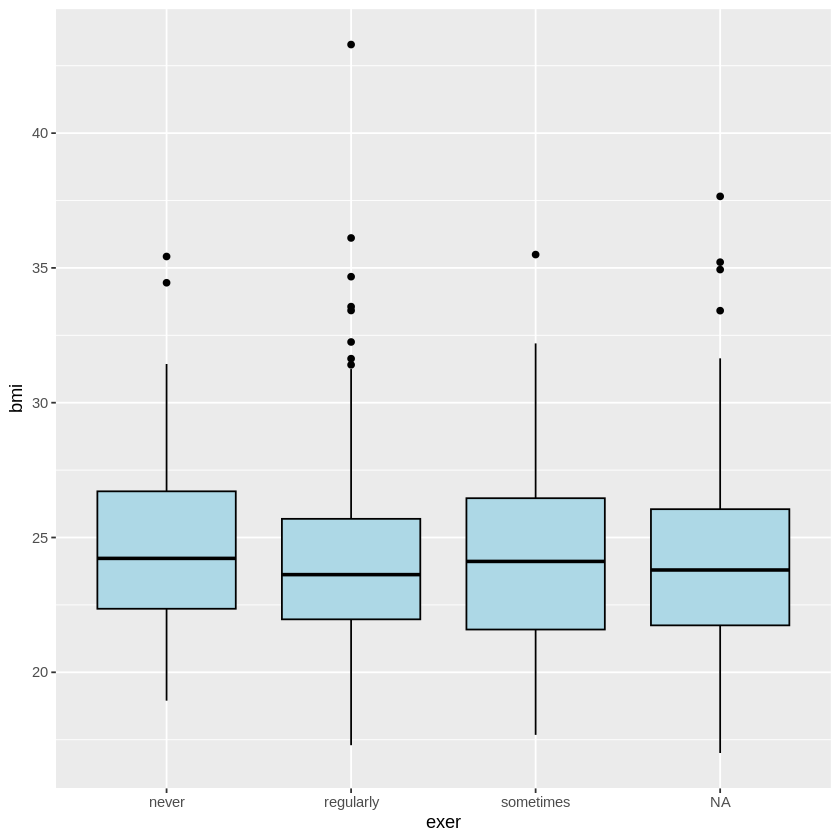

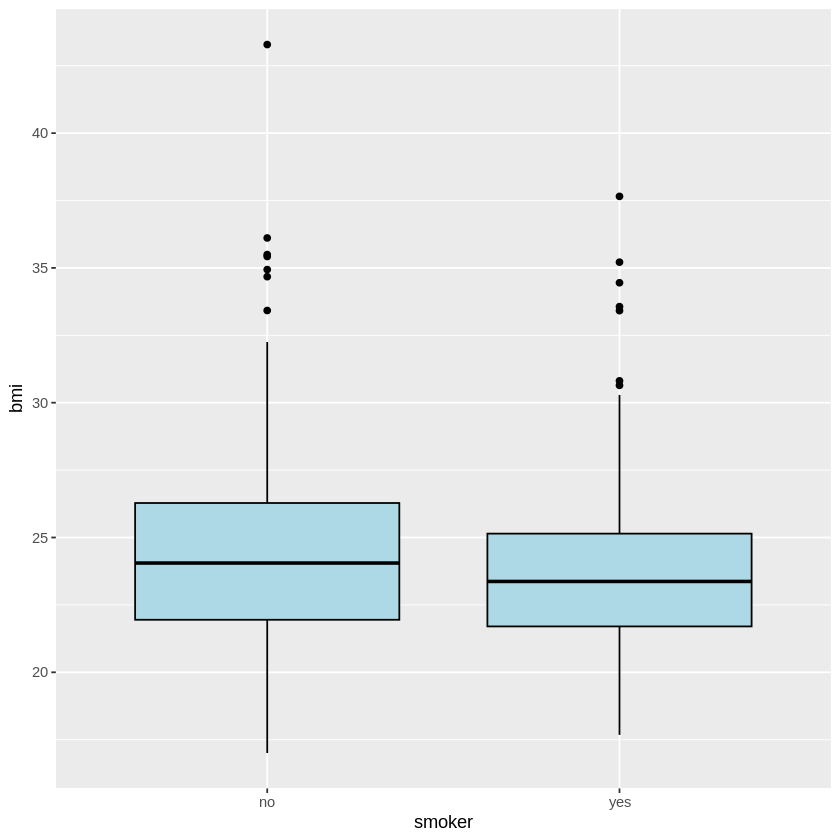

In [17]:
# We also may wish to look at relationships between the categorical variables and continuous. eg.
ggplot(dat,aes(sex,bmi)) +
    geom_boxplot(color='black', fill='lightblue')
ggplot(dat,aes(exer,bmi)) +
    geom_boxplot(color='black', fill='lightblue')
ggplot(dat,aes(smoker,bmi)) +
    geom_boxplot(color='black', fill='lightblue')

#### Analytical notes:

We have just looked at the relationship between the three categorical variables and one of the continuous variables (BMI) and can see that there is a reasonably clear relationship between sex and BMI - with males tending towards a slightly higher BMI. There are some small differences in BMI across exercise groups and by smoking status. We would probably need to look at these a little closer. A good way to do this would be to run a comparison of means across groups and possibly t-tests or ANOVA to assess group differences.

### For two categorical variables...

In [18]:
# For two categorical variables a cross-tab is usually useful, maybe with a chi-square test. eg.
table(dat$sex,dat$exer)
round(prop.table(table(dat$sex,dat$exer),1),digits=2)
chisq.test(dat$sex,dat$exer)

table(dat$sex,dat$smoker)
round(prop.table(table(dat$sex,dat$smoker),1),digits=2)
chisq.test(dat$sex,dat$smoker)

table(dat$smoker,dat$exer)
round(prop.table(table(dat$smoker,dat$exer),1),digits=2)
chisq.test(dat$smoker,dat$exer)

        
         never regularly sometimes
  female    37       114        40
  male      22       125        35

        
         never regularly sometimes
  female  0.19      0.60      0.21
  male    0.12      0.69      0.19


	Pearson's Chi-squared test

data:  dat$sex and dat$exer
X-squared = 4.4386, df = 2, p-value = 0.1087


        
          no yes
  female 189  84
  male   245 101

        
           no  yes
  female 0.69 0.31
  male   0.71 0.29


	Pearson's Chi-squared test with Yates' continuity correction

data:  dat$sex and dat$smoker
X-squared = 0.11394, df = 1, p-value = 0.7357


     
      never regularly sometimes
  no     41       187        48
  yes    18        52        27

     
      never regularly sometimes
  no   0.15      0.68      0.17
  yes  0.19      0.54      0.28


	Pearson's Chi-squared test

data:  dat$smoker and dat$exer
X-squared = 6.7565, df = 2, p-value = 0.03411


#### Analytical notes:
There is a relationship between exercise and smoking with a smaller proportion of smokers exercising regularly (54%) compared to non-smokers (68%). This difference is significant based on a Chi-Square test of association (p<0.05).


## It is likely that you would now embark on some data cleaning to deal with some of the issues encountered....

For example, let's remove the two observations for height that are problematic. Decision is to set these to "NA" because we believe they were errors. It is important to document your decision whatever it may be.

In [19]:
# Create a new variable for height called height_adj
dat.cont$height_adj <- dat.cont$height
# Assign any implausible values to NA
dat.cont$height_adj[dat.cont$height<110] <- NA
# Have a look at the revised summary stats
des2<- describe(dat.cont[,c('height','height_adj')])
des2[,c("n","mean","sd","median","min","max","skew","kurtosis")]

,n,mean,sd,median,min,max,skew,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
height,617,170.1724,11.35570,170.5,67,195.5,-1.544670126,11.9447675
height_adj,615,170.4543,10.19491,170.5,140,195.5,-0.008923137,-0.6288696


Re-run the histograms using new version of age variable

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 278 rows containing non-finite outside the scale range (`stat_bin()`).”


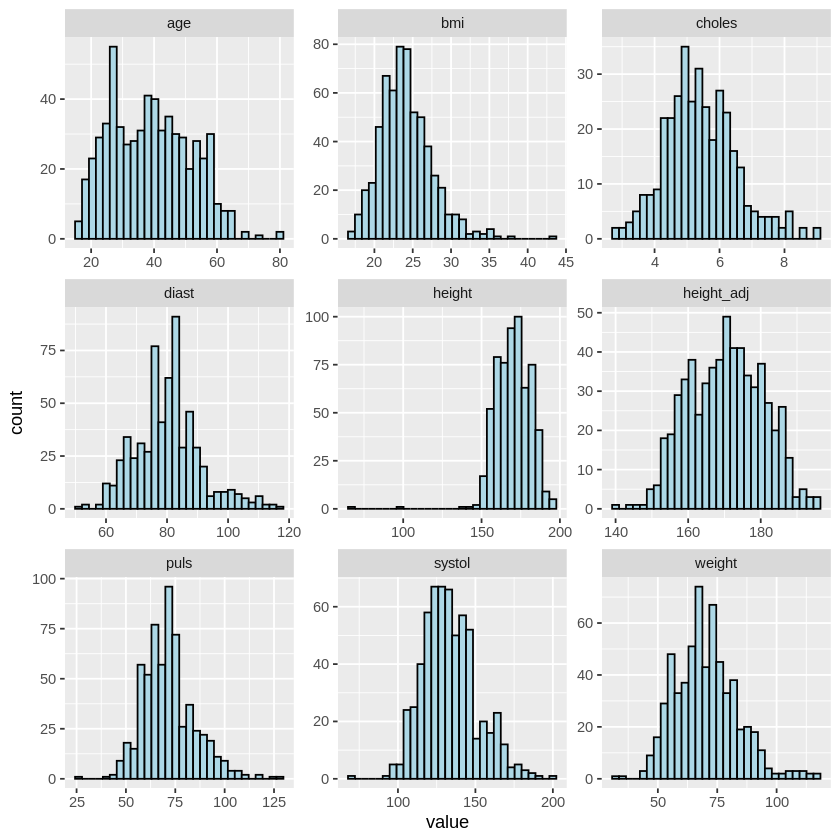

In [20]:
# Now check distribution again using the adjusted height variable
dat.cont %>%
  gather() %>%
  ggplot(aes(value)) +
    facet_wrap(~ key, scales = "free") +
    geom_histogram(color='black', fill='lightblue')

Re-run the scatterplots...

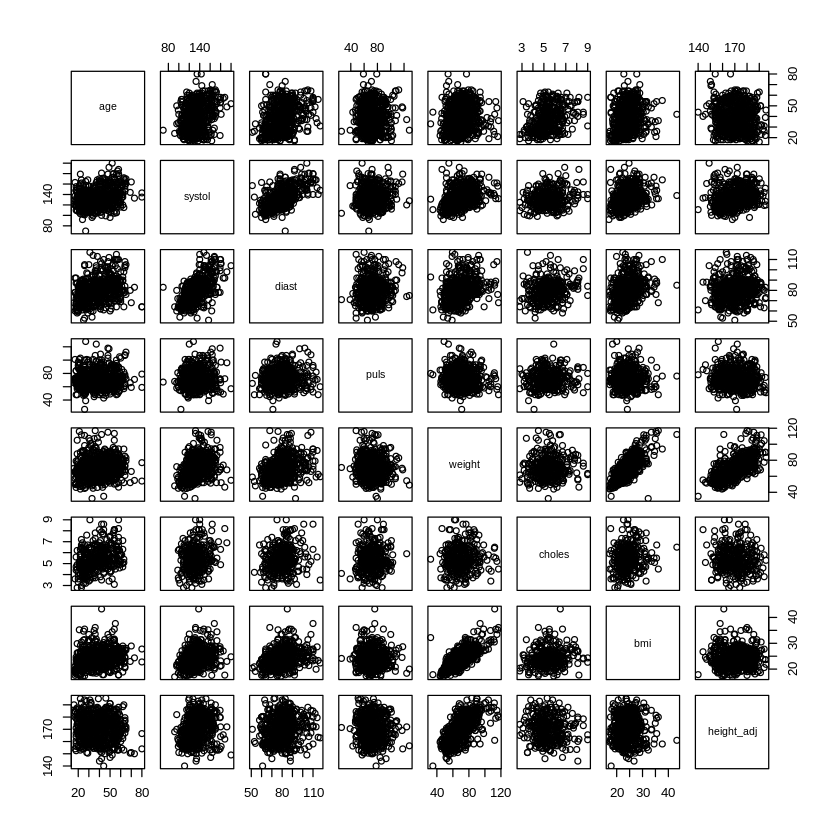

In [21]:
# This re-runs the scatterplots excluding the original height variable
pairs(dat.cont[,-5])